# 💧 Pump It Up: Data Mining the Water Table

## 📌 Problem Overview

In this competition, the goal is to predict the **operational status of water pumps** across Tanzania. These pumps are crucial for providing clean water, and predicting their condition can help improve maintenance and resource allocation.

Each water pump is classified into one of three categories:
- **functional** → the pump is working properly
- **functional needs repair** → the pump is working but needs fixing
- **non functional** → the pump is not working

---

## 🎯 Objective

The objective is to build a machine learning model that accurately predicts the status of each water pump based on various features such as:
- Location (latitude, longitude, region)
- Installer and funder information
- Construction year
- Water quality and quantity
- Management type, etc.

---

## 📊 Evaluation Metric

The performance of the model is evaluated using **Classification Rate (Accuracy)**:

- It measures the proportion of correct predictions made by the model.
- Value ranges from **0 to 1**
- Higher is better 🚀

---

## 🧠 Machine Learning Task

- **Type:** Multi-class Classification  
- **Target Variable:** `status_group`  
- **Classes:** 3 (functional, needs repair, non functional)

---

## 🛠️ Approach Strategy

We will follow a structured ML pipeline:

1. Data Understanding & Exploration  
2. Data Cleaning  
3. Feature Engineering  
4. Encoding Categorical Variables  
5. Model Building (Baseline → Advanced)  
6. Evaluation & Improvement  

---

## 🚀 Goal

Build a robust model that generalizes well and achieves a high accuracy score on unseen test data.

In [1]:
# 📊 Data Handling
import pandas as pd
import numpy as np

# 📈 Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ⚙️ Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 🤖 Models
from sklearn.ensemble import RandomForestClassifier

# 📏 Evaluation
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
#Stratified Fold
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 🔍 Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand:
- Structure of the data
- Missing values
- Distribution of features
- Relationships between variables

This step is crucial for making informed decisions during preprocessing and modeling.

In [2]:
test=pd.read_csv('Downloads/702ddfc5-68cd-4d1d-a0de-f5f566f76d91.csv')
train=pd.read_csv('Downloads/4910797b-ee55-40a7-8668-10efd5c1b960.csv')
labels=pd.read_csv('Downloads/0bf8bc6e-30d0-4c50-956a-603fc693d966.csv')

In [3]:
train.shape

(59400, 40)

In [4]:
train.head(2)

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


In [5]:
labels.head()

,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional


In [6]:
data=train.merge(labels,on='id')

In [7]:
data.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [8]:
data.shape

(59400, 41)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

## 🎯 Target Variable Analysis

We first analyze the target variable `status_group` to understand:
- Class distribution
- Whether the dataset is balanced or imbalanced

This is important because imbalance can affect model performance.

In [10]:
data['status_group'].value_counts()

status_group
functional                 32259
non functional             22824
functional needs repair     4317
Name: count, dtype: int64

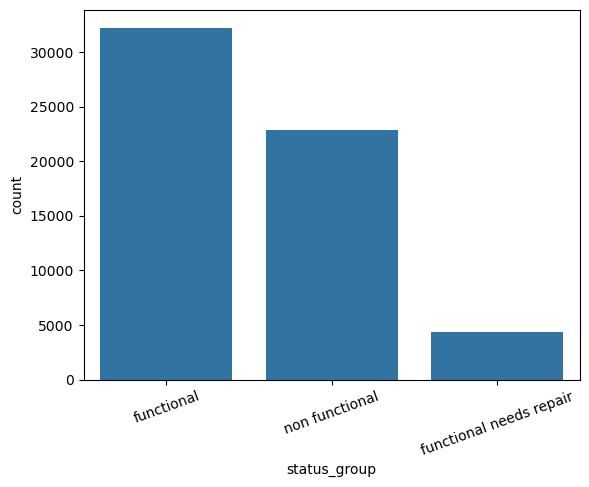

In [11]:
sns.countplot(x="status_group", data=data)
plt.xticks(rotation=20)
plt.show()

### 🧠 Observations

- The dataset is moderately imbalanced
- The "functional needs repair" class is significantly underrepresented
- The other two classes are relatively balanced

👉 This may cause the model to struggle in predicting the minority class

## 🧹 Missing Values Analysis

Understanding missing values helps us decide:
- Which columns to clean
- Which to drop
- Which to fill

In [12]:
missing=data.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

scheme_name          28810
scheme_management     3878
installer             3655
funder                3637
public_meeting        3334
permit                3056
subvillage             371
wpt_name                 2
dtype: int64

In [13]:
missing_percent = (data.isnull().sum() / len(data)) * 100
missing_percent.sort_values(ascending=True)
missing_percent[missing_percent>0.000000]

funder                6.122896
installer             6.153199
wpt_name              0.003367
subvillage            0.624579
public_meeting        5.612795
scheme_management     6.528620
scheme_name          48.501684
permit                5.144781
dtype: float64

### 🧠 Missing Value Observations

- `scheme_name` has a very high percentage of missing values (~48%)
  → This column may not be useful and can be dropped

- Several columns like `funder`, `installer`, `scheme_management`, `public_meeting`, and `permit`
  have moderate missing values (~5–6%)
  → These can be filled with a placeholder such as "unknown"

- Columns like `subvillage` and `wpt_name` have very few missing values
  → These can be safely retained

👉 Overall:
- Most features are usable
- Only a few require careful handling

## 🔥 High Cardinality Features

High cardinality refers to columns that have a very large number of unique values.

These features can be problematic because:
- They increase model complexity
- They may cause overfitting
- Encoding them can become inefficient

We need to identify such columns and handle them carefully.

In [14]:
for col in data.select_dtypes(include="object").columns:
    print(col, data[col].nunique())

date_recorded 356
funder 1896
installer 2145
wpt_name 37399
basin 9
subvillage 19287
region 21
lga 125
ward 2092
public_meeting 2
recorded_by 1
scheme_management 11
scheme_name 2695
permit 2
extraction_type 18
extraction_type_group 13
extraction_type_class 7
management 12
management_group 5
payment 7
payment_type 7
water_quality 8
quality_group 6
quantity 5
quantity_group 5
source 10
source_type 7
source_class 3
waterpoint_type 7
waterpoint_type_group 6
status_group 3


### 🧠 Observations

- Some features like `wpt_name` have extremely high cardinality
  → These behave like unique identifiers and should be dropped

- Features like `funder` and `installer` have many unique values
  → These can be grouped into top categories and "other"

👉 This reduces noise and improves model performance

## 🧹 Data Cleaning Plan

Before building our baseline model, we will:

1. Drop irrelevant columns (`wpt_name`, `scheme_name`)
2. Handle missing values:
   - Categorical → fill with "unknown"
   - Numerical → fill with median
3. Reduce high-cardinality features:
   - Group rare categories in `funder` and `installer`
4. Encode categorical variables using Label Encoding

This prepares the dataset for modeling.

In [15]:
test_ids=test['id']

In [16]:
data=data.drop(columns=['wpt_name','scheme_name','id'])
test = test.drop(columns=["wpt_name", "scheme_name",'id'])

In [17]:
# Fill categorical
for col in data.select_dtypes(include="object").columns:
    data[col] = data[col].fillna("unknown")
# Fill numerical
for col in data.select_dtypes(exclude="object").columns:
    data[col] = data[col].fillna(data[col].median())


# Fill categorical
for col in test.select_dtypes(include="object").columns:
    test[col] = test[col].fillna("unknown")
# Fill numerical
for col in test.select_dtypes(exclude="object").columns:
    test[col] = test[col].fillna(test[col].median())

In [18]:
top_installers = data["installer"].value_counts().head(10).index
data["installer"] = data["installer"].apply(
    lambda x: x if x in top_installers else "other"
)

top_funders = data["funder"].value_counts().head(10).index
data["funder"] = data["funder"].apply(
    lambda x: x if x in top_funders else "other"
)


In [19]:
test["funder"] = test["funder"].apply(
    lambda x: x if x in top_funders else "other"
)

test["installer"] = test["installer"].apply(
    lambda x: x if x in top_installers else "other"
)

# 🧠 Feature Engineering

In this section, we create new features to improve model performance.

The goal is to:
- Extract meaningful information from existing features
- Help the model better distinguish between classes
- Improve performance, especially for the minority class

We focus on:
- Age of the pump
- Date-related features
- Cleaning inconsistent values

In [21]:
#fe-2
data["age"] = 2025 - data["construction_year"]
#fe-3
data["date_recorded"] = pd.to_datetime(data["date_recorded"])
data["recorded_year"] = data["date_recorded"].dt.year
data["recorded_month"] = data["date_recorded"].dt.month
#fe-4
data["age_group"] = pd.cut(
    data["age"],
    bins=[0, 10, 20, 50, 100],
    labels=["new", "medium", "old", "very_old"]
)
#fe-5
data.loc[data["gps_height"] < 0, "gps_height"] = np.nan
data["gps_height"] = data["gps_height"].fillna(data["gps_height"].median())
#fe-6
data["lat_round"] = data["latitude"].round(1)
data["long_round"] = data["longitude"].round(1)

#fe-7
data["population"] = data["population"].replace(0, data["population"].median())

#fe-8
top_mgmt = data["management"].value_counts().nlargest(5).index

data["management"] = data["management"].apply(
    lambda x: x if x in top_mgmt else "other"
)
#fe-9
data["pop_per_height"] = data["population"] / (data["gps_height"] + 1)
data["age_per_population"] = data["age"] / (data["population"] + 1)



In [21]:
# test["construction_year"] = test["construction_year"].replace(0, np.nan)
# test["construction_year"] = test["construction_year"].fillna(data["construction_year"].median())

test["age"] = 2025 - test["construction_year"]

test["age_group"] = pd.cut(
    test["age"],
    bins=[0, 10, 20, 50, 100],
    labels=["new", "medium", "old", "very_old"]
)

test["date_recorded"] = pd.to_datetime(test["date_recorded"])
test["recorded_year"] = test["date_recorded"].dt.year
test["recorded_month"] = test["date_recorded"].dt.month


test.loc[test["gps_height"] < 0, "gps_height"] = np.nan
test["gps_height"] = test["gps_height"].fillna(test["gps_height"].median())


test["lat_round"] = test["latitude"].round(1)
test["long_round"] = test["longitude"].round(1)

test["population"] = test["population"].replace(0, test["population"].median())

top_mgmt = test["management"].value_counts().nlargest(5).index

test["management"] = test["management"].apply(
    lambda x: x if x in top_mgmt else "other"
)

test["pop_per_height"] = test["population"] / (test["gps_height"] + 1)
test["age_per_population"] = test["age"] / (test["population"] + 1)


In [22]:
data = data.drop(columns=["date_recorded"])
test = test.drop(columns=["date_recorded"])

### 🧠 Feature Engineering Insights

- The `age` feature captures how old a pump is, which is strongly related to its condition
- Extracting year and month from `date_recorded` helps capture temporal patterns
- Grouping age into categories simplifies model learning

👉 These features are expected to improve prediction, especially for pumps needing repair

In [23]:
y = data["status_group"]# save target
drop_cols = [
    "subvillage",
    "status_group"
]
data = data.drop(columns=drop_cols)  # remove from features

In [24]:
data.columns

Index(['amount_tsh', 'funder', 'gps_height', 'installer', 'longitude',
       'latitude', 'num_private', 'basin', 'region', 'region_code',
       'district_code', 'lga', 'ward', 'population', 'public_meeting',
       'recorded_by', 'scheme_management', 'permit', 'construction_year',
       'extraction_type', 'extraction_type_group', 'extraction_type_class',
       'management', 'management_group', 'payment', 'payment_type',
       'water_quality', 'quality_group', 'quantity', 'quantity_group',
       'source', 'source_type', 'source_class', 'waterpoint_type',
       'waterpoint_type_group', 'age', 'recorded_year', 'recorded_month',
       'age_group', 'lat_round', 'long_round', 'pop_per_height',
       'age_per_population'],
      dtype='object')

In [25]:
target_le = LabelEncoder()
y = target_le.fit_transform(y)

In [26]:
X=data

In [27]:

# Combine ONLY for encoding (safe)
combined = pd.concat([X, test], axis=0)

for col in combined.columns:
    if combined[col].dtype == "object" or str(combined[col].dtype) == "category":
        combined[col] = combined[col].astype(str)
        combined[col] = LabelEncoder().fit_transform(combined[col])

# Split back
X = combined.iloc[:len(X)]
test = combined.iloc[len(X):]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [30]:
preds = model.predict(X_val)
accuracy_score(y_val, preds)

0.8057239057239057

In [31]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance.head(20))

                  feature  importance
4               longitude    0.105108
5                latitude    0.096876
29         quantity_group    0.053182
40             long_round    0.048432
28               quantity    0.048063
2              gps_height    0.044641
12                   ward    0.043318
41         pop_per_height    0.042906
39              lat_round    0.038702
42     age_per_population    0.032896
35                    age    0.025741
13             population    0.025711
11                    lga    0.025387
18      construction_year    0.025346
33        waterpoint_type    0.022653
21  extraction_type_class    0.019189
10          district_code    0.017586
37         recorded_month    0.017362
1                  funder    0.017242
20  extraction_type_group    0.017214


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_val, preds))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84      6457
           1       0.51      0.35      0.41       851
           2       0.84      0.78      0.81      4572

    accuracy                           0.81     11880
   macro avg       0.72      0.67      0.69     11880
weighted avg       0.80      0.81      0.80     11880



### 🧠 Model Performance Analysis

- The model performs well on the majority classes:
  - "functional" and "non functional"

- However, it struggles with the minority class:
  - "functional needs repair"
  - Low recall (~35%) indicates many such cases are missed

👉 This suggests:
- Class imbalance is affecting performance
- The model is biased toward majority classes

👉 Next step:
- Improve feature representation to better capture repair cases

In [31]:
model.fit(X, y)

RandomForestClassifier(class_weight='balanced', random_state=42)

## 🚀 XGBoost Model

We use XGBoost to improve performance over Random Forest.

XGBoost:
- Builds trees sequentially
- Learns from previous mistakes
- Handles complex patterns better

Expected improvement:
- Better accuracy
- Better handling of minority class

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_model = XGBClassifier(
    n_estimators=500,          # increase trees
    learning_rate=0.03,        # slower learning
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)
scores = cross_val_score(xgb_model, X, y, cv=skf, scoring="accuracy")

print("CV Scores:", scores)
print("Mean CV Score:", scores.mean())

In [ ]:
xgb_model.fit(X,y)

## 🌿 LightGBM Model

LightGBM is a gradient boosting framework that is:
- Faster than XGBoost
- More efficient with large datasets
- Often performs better on tabular data

It uses:
- Leaf-wise tree growth (more complex patterns)
- Histogram-based splitting

---

### 🎯 Objective

- Improve performance over Random Forest
- Capture complex relationships in data
- Prepare for ensembling with other models

In [43]:
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008431 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2392
[LightGBM] [Info] Number of data points in the train set: 47520, number of used features: 40
[LightGBM] [Info] Start training from score -0.610699
[LightGBM] [Info] Start training from score -2.618149
[LightGBM] [Info] Start training from score -0.956876


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=500,
               random_state=42, subsample=0.8)

In [45]:
lgb_preds = lgb_model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, lgb_preds))
print(classification_report(y_val, lgb_preds))

Accuracy: 0.8002525252525252
              precision    recall  f1-score   support

           0       0.78      0.92      0.84      6457
           1       0.64      0.27      0.38       851
           2       0.86      0.73      0.79      4572

    accuracy                           0.80     11880
   macro avg       0.76      0.64      0.67     11880
weighted avg       0.80      0.80      0.79     11880



In [ ]:
lgb_model.fit(X, y)

## ⚙️ LightGBM Hyperparameter Tuning with Cross Validation

To improve model performance, we tune LightGBM using **5-fold Stratified Cross Validation**.

This helps:
- Ensure stable performance across folds
- Reduce variance in evaluation
- Identify better hyperparameters

---

### 🎯 Objective

- Improve LightGBM performance
- Make it competitive with Random Forest
- Enhance ensemble performance

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_model = LGBMClassifier(
    n_estimators=800,          # more trees
    learning_rate=0.03,        # slower learning
    num_leaves=60,             # more complexity
    max_depth=-1,
    min_child_samples=15,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

scores = cross_val_score(lgb_model, X, y, cv=skf, scoring="accuracy")

print("CV Scores:", scores)
print("Mean CV Score:", scores.mean())

# 🔥 Model Stacking (Meta Learning)

## 📌 Overview

To further improve performance, we use **stacking**, an advanced ensembling technique where predictions from multiple base models are used as inputs to a meta model.

Instead of manually assigning weights (like averaging), stacking allows a model to **learn how to best combine predictions**.

---

## 🧠 Idea

We train multiple base models:

* LightGBM (LGB)
* Random Forest (RF)
* XGBoost (XGB)

Each model outputs **class probabilities** for every sample.

These probabilities are then combined to form a new dataset:

```
[LGB_probs | RF_probs | XGB_probs]
```

This becomes the input for the **meta model**.

---

## 🔁 Out-of-Fold (OOF) Predictions

To avoid data leakage, we generate **Out-of-Fold (OOF) predictions** using Stratified K-Fold:

* Split data into folds
* Train on (k-1) folds
* Predict on the remaining fold (unseen data)

This ensures:

* Each prediction is made on unseen data
* Meta model learns from **realistic predictions**

---

## 🧩 Stacking Pipeline

1. Generate OOF predictions for each base model
2. Combine predictions using `np.hstack()`
3. Train a meta model (Logistic Regression) on OOF predictions
4. Train base models on full data
5. Generate test predictions
6. Pass test predictions to meta model for final output

---

## 🤖 Meta Model

We use **Logistic Regression** as the meta model:

* Learns patterns in base model outputs
* Adapts weights dynamically for each sample
* Improves generalization

---

## 🎯 Benefits

* Combines strengths of multiple models
* Reduces individual model weaknesses
* Learns optimal combination strategy
* Often improves leaderboard performance

---

## 💡 Key Insight

> Stacking is not just combining models —
> it is **training a model to understand other models**.

---

## 🚀 Result

Stacking led to a performance improvement on both CV and leaderboard, demonstrating better generalization compared to individual models and simple averaging.


In [31]:
y = pd.Series(y, index=data.index)

In [39]:
skf = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

oof_lgb = np.zeros((len(X), 3))
oof_rf = np.zeros((len(X), 3))
oof_xgb = np.zeros((len(X), 3))

for train_idx, val_idx in skf.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    lgb_model.fit(X_tr, y_tr)
    model.fit(X_tr, y_tr)
    xgb_model.fit(X_tr, y_tr)
    
    oof_lgb[val_idx] = lgb_model.predict_proba(X_val)
    oof_rf[val_idx] = model.predict_proba(X_val)
    oof_xgb[val_idx] = xgb_model.predict_proba(X_val)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008031 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2592
[LightGBM] [Info] Number of data points in the train set: 50914, number of used features: 42
[LightGBM] [Info] Start training from score -0.610512
[LightGBM] [Info] Start training from score -2.621805
[LightGBM] [Info] Start training from score -0.956447
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007825 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2592
[LightGBM] [Info] Number of data points in the train set: 50914, number of used features: 42
[LightGBM] [Info] Start training from score -0.610512
[LightGBM] [Info] Start training from score -2.621805
[LightGBM] [Info] Start training from score -0.956447
[LightGBM] [Info] Auto-choosing co

In [40]:
stack_X = np.hstack([oof_lgb, oof_rf,oof_xgb])

In [42]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(max_iter=1000,C=0.5)
meta_model.fit(stack_X, y)

LogisticRegression(C=0.5, max_iter=1000)

In [43]:
# Train full models
lgb_model.fit(X, y)
model.fit(X, y)
xgb_model.fit(X,y)

lgb_test = lgb_model.predict_proba(test)
rf_test = model.predict_proba(test)
xgb_test=xgb_model.predict_proba(test)

stack_test = np.hstack([lgb_test, rf_test,xgb_test])

final_preds = meta_model.predict(stack_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006521 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2598
[LightGBM] [Info] Number of data points in the train set: 59400, number of used features: 42
[LightGBM] [Info] Start training from score -0.610497
[LightGBM] [Info] Start training from score -2.621734
[LightGBM] [Info] Start training from score -0.956482


## 🤝 Model Ensembling

To improve performance, we combine predictions from multiple models:

- Random Forest
- XGBoost
- LightGBM

Instead of relying on a single model, ensembling:
- Reduces model-specific errors
- Improves generalization
- Often leads to better leaderboard performance

We use probability averaging (soft voting).

In [ ]:
lgb_proba = lgb_model.predict_proba(test)

In [40]:
rf_proba = model.predict_proba(test)

In [40]:
xgb_proba=xgb_model.predict_proba(test)

## ⚖️ Optimizing Ensemble Weights

Instead of manually choosing weights, we systematically try different combinations of weights for Random Forest and LightGBM.

This helps us:

Find the best balance between models

Maximize validation accuracy

Improve leaderboard performance

We evaluate combinations using validation data.

In [39]:
best_score = 0
best_weights = None

# Get validation probabilities
rf_val = model.predict_proba(X_val)
lgb_val = lgb_model.predict_proba(X_val)

# Try different weights
for w in np.arange(0.5, 0.9, 0.05):  # RF weight
    lgb_w = 1 - w

    ensemble_val = w * rf_val + lgb_w * lgb_val
    preds = np.argmax(ensemble_val, axis=1)

    score = accuracy_score(y_val, preds)

    print(f"RF: {w:.2f}, LGB: {lgb_w:.2f} → {score:.4f}")

    if score > best_score:
        best_score = score
        best_weights = (w, lgb_w)

print("\nBest weights:", best_weights)
print("Best score:", best_score)

RF: 0.50, LGB: 0.50 → 0.8444
RF: 0.55, LGB: 0.45 → 0.8397
RF: 0.60, LGB: 0.40 → 0.8366
RF: 0.65, LGB: 0.35 → 0.8323
RF: 0.70, LGB: 0.30 → 0.8279
RF: 0.75, LGB: 0.25 → 0.8235
RF: 0.80, LGB: 0.20 → 0.8203
RF: 0.85, LGB: 0.15 → 0.8162

Best weights: (np.float64(0.5), np.float64(0.5))
Best score: 0.8443602693602693


In [41]:
ensemble_proba = (
    0.5 * rf_proba +
    0.5 * lgb_proba
)

In [42]:
final_preds = np.argmax(ensemble_proba, axis=1)
final_preds = target_le.inverse_transform(final_preds)
final_preds = target_le.inverse_transform(final_preds)

In [45]:
submission = pd.DataFrame({
    "id": test_ids,
    "status_group": final_preds
})
submission.to_csv("pump_submission.csv", index=False)
